# Deep Learning Assignment - Nonlinear Regression Variants

**Goal:** Build a 3-hidden-layer neural network for nonlinear regression using synthetic data with **3 input variables**.

**Synthetic equation used in this notebook**

\[
y = \sin(x_1) + 0.5x_2^2 - 0.3x_3^3 + 0.2x_1x_2 - 0.1x_2x_3 + \epsilon
\]

where \(\epsilon\) is small Gaussian noise.

## What this notebook demonstrates
- 3-input nonlinear synthetic data generation
- train/validation split
- 3-hidden-layer neural network
- loss tracking across epochs
- final output comparison
- a **4D-style plot** using 3D coordinates + color for the target value
- clean section-wise code organization for video walkthrough

> You can narrate this notebook section by section during the assignment demo.


## Variant E(ii) - TensorFlow with built-in layers

This version uses Keras built-in layers in a standard sequential model.

In [1]:
!pip -q install tensorflow scikit-learn matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

SEED = 42
np.random.seed(SEED)

def make_data(n_samples=1800, noise=0.08):
    x1 = np.random.uniform(-3, 3, n_samples)
    x2 = np.random.uniform(-2, 2, n_samples)
    x3 = np.random.uniform(-1.5, 1.5, n_samples)

    y = (
        np.sin(x1)
        + 0.5 * (x2 ** 2)
        - 0.3 * (x3 ** 3)
        + 0.2 * x1 * x2
        - 0.1 * x2 * x3
        + np.random.normal(0, noise, n_samples)
    )

    X = np.column_stack([x1, x2, x3]).astype(np.float32)
    y = y.reshape(-1, 1).astype(np.float32)
    return X, y

X, y = make_data()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (1260, 3) (1260, 1)
Val  : (270, 3) (270, 1)
Test : (270, 3) (270, 1)


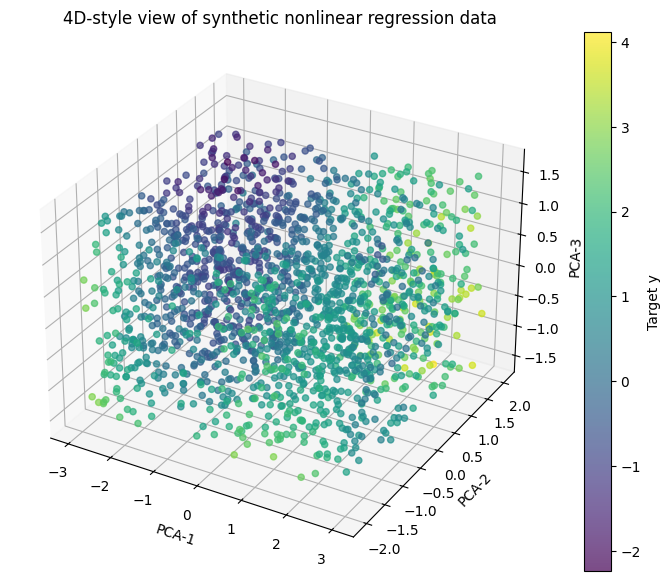

In [3]:
# 4D-style plot:
# - 3D position = PCA projection of the 3 input variables
# - color = target value y

pca = PCA(n_components=3)
X_vis = pca.fit_transform(X)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_vis[:, 0], X_vis[:, 1], X_vis[:, 2], c=y.flatten(), alpha=0.7)
ax.set_title("4D-style view of synthetic nonlinear regression data")
ax.set_xlabel("PCA-1")
ax.set_ylabel("PCA-2")
ax.set_zlabel("PCA-3")
fig.colorbar(scatter, ax=ax, label="Target y")
plt.show()

In [4]:
import tensorflow as tf
tf.random.set_seed(SEED)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(3,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(24, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,337 (5.22 KB)

 Trainable params: 1,337 (5.22 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=250,
    batch_size=64,
    verbose=0
)

print("Training complete.")

Training complete.


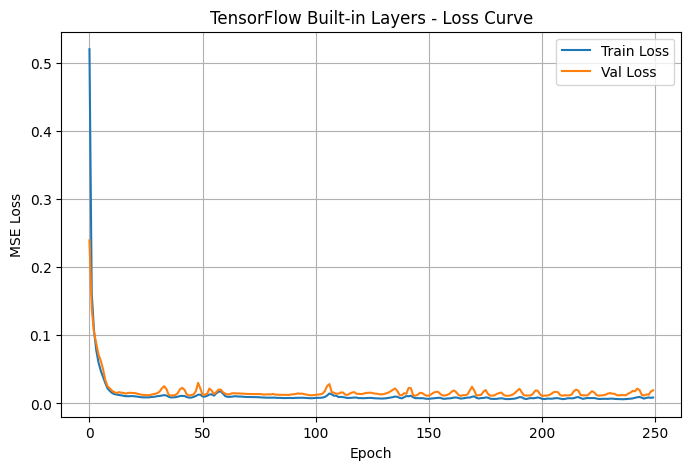

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("TensorFlow Built-in Layers - Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
import numpy as np

def regression_report(y_true, y_pred, label="Model"):
    y_true = np.array(y_true).reshape(-1)
    y_pred = np.array(y_pred).reshape(-1)

    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

    print(f"\n{label} Regression Metrics")
    print("-" * 40)
    print(f"MSE  : {mse:.6f}")
    print(f"RMSE : {rmse:.6f}")
    print(f"MAE  : {mae:.6f}")
    print(f"R²   : {r2:.6f}")


TensorFlow Built-in Layers Network Regression Metrics
----------------------------------------
MSE  : 0.016750
RMSE : 0.129423
MAE  : 0.106300
R²   : 0.986859


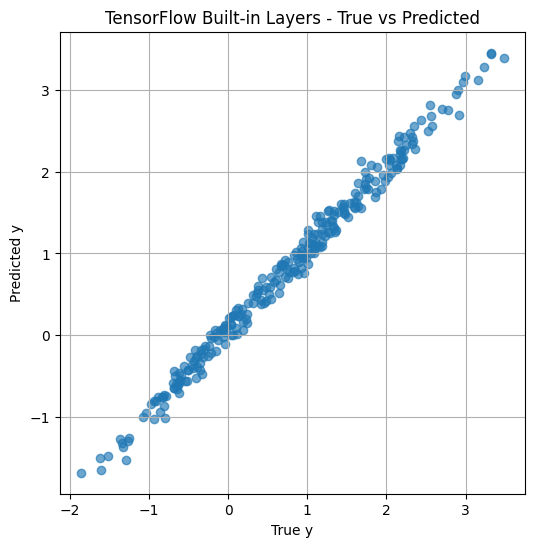

In [9]:
y_test_pred = model.predict(X_test, verbose=0)
regression_report(y_test, y_test_pred, label="TensorFlow Built-in Layers Network")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.65)
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("TensorFlow Built-in Layers - True vs Predicted")
plt.grid(True)
plt.show()